In [1]:
import dask
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as patches
import numpy as np
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmcrameri as cm
import os
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.patches as patches
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe
import warnings
from cmcrameri import cm
import cfgrib
import glob

import babet as bb
import atmicp

warnings.filterwarnings("ignore", category=FutureWarning)
dask.config.set(**{'array.slicing.split_large_chunks': True})

In [2]:
atmicp.style.set_style()

# climate scenario colours from the shared style
CLIM = {'pi': atmicp.style.climate_color('1870'),        # blue
        'curr': atmicp.style.climate_color('present'),   # grey
        'incr': atmicp.style.climate_color('future1')}   # orange

LABEL = {'pi': 'pre-industrial', 'curr': 'current', 'incr': 'increased'}

# one linestyle per perturbation, so climate stays the only thing colour encodes
LS = {'iterated': '-',
      'iterated_short': ':',
      'tq': '--',
      'ocean': '-.',
      'none': '-'}

PERT_LABEL = {'iterated': 'iterated',
              'iterated_short': 'iterated, short',
              'tq': 'delta t+q',
              'ocean': 'ocean only',
              'none': 'unperturbed'}

# Functions from Nick's analysis

Notebook can be found here [Nick's notebook](https://github.com/njleach/counterfactual-forecast-notebooks/blob/main/analysis-notebooks/WWA-region-view.ipynb)

In [3]:
## accumulated variables & scaling factors
accumulated_vars = {'tp':60 * 60 * 24 * 1e3,'ttr':1,'tsr':1,'str':1,'ssr':1,'e':1}
accumulated_var_newunits = {'tp':'mm day$^{-1}$','ttr':'W m$^{-2}$','tsr':'W m$^{-2}$','str':'W m$^{-2}$','ssr':'W m$^{-2}$','e':'m s$^{-1}$'}

## definition to convert accumulated variables to instantaneous:
def accum2rate(ds):
    ds = ds.copy()
    oindex = ds.time
    inidate = pd.to_datetime(oindex[0].values)
    
    # add in conditional for m-climate
    # if 'hDate' in ds.dims:
    #     ds = ds.diff('time') / ( ds.time.diff('time').astype(float) / 1e9 )
    #     ds = ds.reindex(time=oindex)
    #     return ds[1:]
    
    # ds = ds.sel(time=common_timeindex[inidate]).diff('time') / common_timedeltas[inidate]
    ds = ds.diff('time') / ( ds.time.diff('time').astype(float) / 1e9 )
    ds = ds.reindex(time=oindex)
    return ds[1:]

In [4]:
def preproc_ds(ds):
    
    ds = ds.copy().squeeze()
    
    fname = ds.encoding['source'].split('/')[-1].split('.')[0]
    
    if fname[:3] == 'b2m':
        expver = fname.split('_')[0]
        ds = ds.expand_dims({'experiment':[expver]})
    
    # set up aux data
    inidate = pd.to_datetime(ds.time[0].values)
    
    # expand dimensions to include extra info
    ds = ds.expand_dims({'inidate':[inidate]})
    if not 'number' in ds:
        ds = ds.expand_dims({'number':[0]})
        
    # put time dimension at front
    ds = ds.transpose('time',...)
    
    # convert accumulated variables into instantaneous
    for var,sf in accumulated_vars.items():
        if var in ds.keys():
            ds[var][1:] = accum2rate(ds[var]) * sf
            # set first value to equal zero [since it should be zero... but isn't always]
            ds[var][0] = 0
            ds[var].attrs['units'] = accumulated_var_newunits[var]
            
    return ds

In [5]:
## add in preprocessing step for m-climate:

def preproc_mclim(ds):
    
    ds = preproc_ds(ds)
    
    # create index of hours frmo init
    ds_hours = ((ds.time-ds.time.isel(time=0))/1e9/3600).astype(int)
    # change time coord to hours coord + rename
    ds = ds.assign_coords(time=ds_hours).rename(dict(time='hour'))
    
    return ds.isel(inidate=0).drop('inidate')

## nested [[cf, pf], ...] file list, one row per m-climate date, so open_mfdataset
## can concat along ['hDate', 'number'] instead of merging (merge computes the data to check conflicts - very slow)

def mclim_files(path):
    
    dates = sorted(os.path.basename(f) for f in glob.glob(os.path.join(path, 'cf', '*.nc')))
    
    return [[os.path.join(path, member, date) for member in ('cf', 'pf')] for date in dates]

In [6]:
## and one for the z indices

def extract_z_indices(ds):
    
    # get three indices of geopotential height - mean, max & L-O blocking
    z_max = ds.z.sel(latitude=slice(60,35),longitude=slice(230,250)).max(['latitude','longitude'])
    z_block = (ds.z.sel(latitude=40,longitude=slice(230,250)) - ds.z.sel(latitude=60,longitude=slice(230,250))).mean('longitude')
    z_mean = ds.z.sel(latitude=slice(60,35),longitude=slice(230,250)).weighted(np.cos(np.deg2rad(ds.latitude))).mean(['latitude','longitude'])
    
    return xr.merge([z_max.rename('z500_max'),z_mean.rename('z500_mean'),z_block.rename('z500_blo')])

def preproc_z500(ds):
    
    if 'hDate' in ds.dims:
        ds = preproc_mclim(ds)
    else:
        ds = preproc_ds(ds).sel(level=500)
    
    return extract_z_indices(ds)

# Import data

In [7]:
mclim_z500 = xr.open_mfdataset(mclim_files('/network/group/aopp/archive02a/projects/predict/AWH009_LEACH_RELIABLE/COUNTERFACTUAL-FORECASTING/DATA/m-clim/glo100/pl'),preprocess=preproc_z500,combine='nested',concat_dim=['hDate','number'],parallel=True).load()
print('got M-climate')

got M-climate


In [8]:
mclim_sfc = xr.open_mfdataset(mclim_files('/network/group/aopp/archive02a/projects/predict/AWH009_LEACH_RELIABLE/COUNTERFACTUAL-FORECASTING/DATA/postproc/WWAmean/m-clim/sfc'),preprocess=preproc_mclim,combine='nested',concat_dim=['hDate','number']).squeeze().load()
print('got M-climate')

got M-climate


In [9]:
# tcc and swvl1 on top of the defaults, for the corner plot
ifs_sfc = atmicp.Data.get_ifs_data(levtype='sfc', res='US025',
                                   variables=['t2m', 'msl', 'tcwv', 'tcc', 'swvl1'])

Loading 3 file(s) for b2vj (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/US025/sfc/cf


Loading 3 file(s) for b2vj (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/US025/sfc/pf


Loading 3 file(s) for b2vr (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/US025/sfc/cf


Loading 3 file(s) for b2vr (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/US025/sfc/pf


Loading 3 file(s) for b2vl (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/US025/sfc/cf


...

Loading 3 file(s) for b2vq (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/incr/US025/sfc/pf


Loading 3 file(s) for b2vm (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/incr/US025/sfc/cf


Loading 3 file(s) for b2vm (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/incr/US025/sfc/pf


Loading 3 file(s) for b2vn (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/incr/US025/sfc/cf


Loading 3 file(s) for b2vn (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/incr/US025/sfc/pf


In [10]:
ifs_pl = atmicp.Data.get_ifs_data(levtype='pl', res='GLO100')

Loading 3 file(s) for b2vj (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/GLO100/pl/cf


Loading 3 file(s) for b2vj (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/GLO100/pl/pf


Loading 3 file(s) for b2vr (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/GLO100/pl/cf


Loading 3 file(s) for b2vr (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/GLO100/pl/pf


Loading 3 file(s) for b2vl (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/GLO100/pl/cf


...

/home/e/ermis/ATMICP/atmicp/data.py:255: UserWarning: b2vq: missing inidates ['b2vq_2021-06-22.nc', 'b2vq_2021-06-26.nc'] in /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/incr/GLO100/pl/cf
  warnings.warn(
/home/e/ermis/ATMICP/atmicp/data.py:255: UserWarning: b2vq: missing inidates ['b2vq_2021-06-22.nc', 'b2vq_2021-06-26.nc'] in /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/incr/GLO100/pl/pf
  warnings.warn(


Loading 3 file(s) for b2vm (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/incr/GLO100/pl/cf


Loading 3 file(s) for b2vm (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/incr/GLO100/pl/pf


Loading 3 file(s) for b2vn (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/incr/GLO100/pl/cf


Loading 3 file(s) for b2vn (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/incr/GLO100/pl/pf


In [11]:
era5_sfc = xr.open_mfdataset(glob.glob('/network/group/aopp/archive02a/projects/predict/AWH009_LEACH_RELIABLE/COUNTERFACTUAL-FORECASTING/DATA/postproc/WWAmean/era5/sfc/*.nc'))
# convert variables to consistent units:
era5_sfc['tp'] *= 24 * 1000 # convert to mm day-1
era5_sfc['e'] *= 1 / 3600 # convert to m s-1
print('got ERA5')

got ERA5


In [12]:
era5_z500 = extract_z_indices(xr.open_mfdataset(glob.glob('/network/group/aopp/archive02a/projects/predict/AWH009_LEACH_RELIABLE/COUNTERFACTUAL-FORECASTING/DATA/era5/glo100/pl/*.nc'))).load()
print('got ERA5')

got ERA5


In [13]:
# q, u and v for IVT are in the rquv file; the dztw file next to it only has d, z, t and w
era5_glo_pl = xr.open_dataset('/network/group/aopp/archive02a/projects/predict/AWH009_LEACH_RELIABLE/COUNTERFACTUAL-FORECASTING/DATA/era5/glo250/pl/2021_MJJA_rquv.nc')
print('got ERA5')

got ERA5


In [14]:
xr.open_mfdataset(glob.glob('/network/group/aopp/archive02a/projects/predict/AWH009_LEACH_RELIABLE/COUNTERFACTUAL-FORECASTING/DATA/era5/glo100/pl/2021.nc'),preprocess=preproc_ds)


<xarray.Dataset> Size: 1GB
Dimensions:    (number: 1, inidate: 1, time: 2208, latitude: 181, longitude: 360)
Coordinates:
  * number     (number) int64 8B 0
  * inidate    (inidate) datetime64[ns] 8B 2021-06-01
  * time       (time) datetime64[ns] 18kB 2021-06-01 ... 2021-08-31T23:00:00
  * latitude   (latitude) float32 724B 90.0 89.0 88.0 87.0 ... -88.0 -89.0 -90.0
  * longitude  (longitude) float32 1kB 0.0 1.0 2.0 3.0 ... 357.0 358.0 359.0
Data variables:
    z          (time, number, inidate, latitude, longitude) float64 1GB dask.array<chunksize=(2208, 1, 1, 181, 360), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2022-02-25 12:42:21 GMT by grib_to_netcdf-2.24.2: /opt/ecmw...

# Process data

## sfc

In [15]:
# area-average over the PNW box first (same box and plain mean as 08_predictability),
# so each member is one time series and the idxmax/sel below run on a small array.
# Only the 26 Jun - 1 Jul window is read, since the max always falls inside it.
pnw = atmicp.Constants.pnw
box = dict(longitude=slice(pnw[0], pnw[1]), latitude=slice(pnw[3], pnw[2]))
ifs_pnw = (ifs_sfc.sel(time=slice('2021-06-26', '2021-07-01'), **box)
           .mean(['latitude', 'longitude']).compute())

# climate/perturbation combinations that never ran are NaN-filled by the concat
ifs_pnw = ifs_pnw.stack(z=['perturbation', 'climate', 'inidate', 'number']).dropna('z', how='all')

max_t2m_times = ifs_pnw.t2m.idxmax('time')
exp_max_df = ifs_pnw.sel(time=max_t2m_times).to_dataframe()

In [16]:
## we'll use the M-climate for the central lead experiment: 2021-06-22
## thus a valid time of 4-9 days (ie. 2021-06-26:2021-07-01) needs to be selected.
## The M-climate files hold 11 model dates (2021-06-03 to 07-08, 20 hindcast years each), so taking the
## same lead from all of them spreads the valid times over 7 June - 17 July. There is no 22 June date, so
## the two either side of it are kept, each at the lead that gives the same valid times [6 hrly output]
MCLIM_HOURS = {'06-21': slice(120, 241),   # days 5-10
               '06-24': slice(48, 169)}    # days 2-7

def mclim_peak(ds, var):
    """M-climate rows at the peak of `var` in the valid window, for each model date in MCLIM_HOURS."""
    out = []
    for date, hours in MCLIM_HOURS.items():
        ds_date = ds.sel(hDate=ds.hDate.dt.strftime('%m-%d') == date).stack(z=['hDate','number'])
        out.append(ds_date.sel(hour=ds_date[var].sel(hour=hours).idxmax('hour')).to_dataframe())
    return pd.concat(out)

mclim_max_df = mclim_peak(mclim_sfc, 't2m')

In [17]:
## need a few intermediate steps to get the era5 annual max temps
## the files run June-August, so match the month as well as the day: 26-30 June
late_june = (era5_sfc['time.month'] == 6) & era5_sfc['time.day'].isin(range(26, 31))
ds = era5_sfc.sel(time=late_june)
ds = ds.t2m.groupby(ds['time.year']).apply(lambda x: x.idxmax())
era5_max_df = era5_sfc.sel(time=ds.values).to_dataframe()

## pl

In [18]:
# reduce to the z500 box indices first (same as for the M-climate and ERA5),
# so idxmax/sel below run on one small time series per member.
# Only the 26 Jun - 1 Jul window and the 35-60N, 230-250E box are read.
# ifs_pl is already daily, so no resampling is needed.
ifs_z500 = extract_z_indices(
    ifs_pl[['z']].sel(level=500, time=slice('2021-06-26', '2021-07-01'),
                      latitude=slice(60, 35), longitude=slice(230, 250))
).compute()

# climate/perturbation combinations that never ran are NaN-filled by the concat
ifs_z500 = ifs_z500.stack(z=['perturbation', 'climate', 'inidate', 'number']).dropna('z', how='all')

z500_max_times = ifs_z500.z500_max.idxmax('time')
ifs_z500_df = ifs_z500.sel(time=z500_max_times).to_dataframe()

In [19]:
## same M-climate dates and valid window as for t2m; daily means (4 x 6-hourly) of 26-30 June, as for ERA5
mclim_z500_df = mclim_peak(mclim_z500.coarsen(hour=4,boundary='trim').mean(), 'z500_max')

In [20]:
## need a few intermediate steps to get the era5 z500 indices dataframe (26-30 June, as for t2m)
late_june = (era5_z500['time.month'] == 6) & era5_z500['time.day'].isin(range(26, 31))
ds = era5_z500.sel(time=late_june)
ds = ds.z500_max.resample(time='1d').mean()
ds = ds.groupby(ds['time.year']).apply(lambda x: x.idxmax())
era5_z500_df = era5_z500.resample(time='1d').mean().sel(time=ds.values).to_dataframe()

# Atmospheric river

In [21]:
## integrate over the levels the IFS runs and ERA5 share, so the ERA5 point on the
## corner plot is computed the same way as the ensemble (the IFS runs also have
## 600, 400 and 300 hPa, the ERA5 files do not)
IVT_LEVELS = [1000, 925, 850, 700, 500, 250]

def get_IVT(ds, levels=IVT_LEVELS):
    """Vertically integrated vapour transport (kg m-1 s-1), 1000-250 hPa.

    Levels are sorted to increasing pressure and integrated in Pa, so the sign and
    units come out right whichever way round the file stores them (the IFS files
    run 1000 -> 200 hPa, the ERA5 ones 10 -> 1000 hPa).
    """
    ds = ds[['q', 'u', 'v']].sel(level=levels).sortby('level')
    ds = ds.assign_coords(level=ds.level * 100.)   # hPa -> Pa

    out = xr.Dataset()
    out['q_u'] = (ds.q * ds.u).integrate('level') / 9.80665
    out['q_v'] = (ds.q * ds.v).integrate('level') / 9.80665

    return out

In [22]:
## IVT (kg m-1 s-1) above which a point on the section counts as AR; the same
## threshold as Nick's 3, which was in hPa-integrated units
AR_THRESHOLD = 300

def get_AR_mag_dir(ds, threshold=AR_THRESHOLD):

    # copy dataframe
    ds = ds.copy()

    # interpolate to give a little more granularity in latitude
    ds = ds.interp(latitude=np.arange(30,70,0.1))

    # first compute magnitude & direction of IVT (degrees anticlockwise from east)
    m = (ds.q_u**2 +ds.q_v**2)**(1/2)
    d = np.degrees(np.arctan2(ds.q_v, ds.q_u))

    ## now "find" AR
    AR = m.where(m>threshold)
    AR_loc = xr.where(m>threshold,m.latitude,np.nan)

    # get weighted average latitude
    lat_out = (AR*AR_loc).sum('latitude')/AR.sum('latitude')
    # get average strength
    m_out = AR.mean('latitude')
    # get weighted average direction
    d_out = (AR*d).sum('latitude')/AR.sum('latitude')
    # get "width"
    w_out = AR_loc.max('latitude') - AR_loc.min('latitude')

    return xr.merge([lat_out.rename('AR_lat'),m_out.rename('AR_strength'),d_out.rename('AR_dir'),w_out.rename('AR_width')])

In [23]:
# The AR is measured on the 220E section over 24-25 June, so only that section is
# read: IVT over the whole of ifs_pl would mean reading all ~800 GB of it.
# ifs_pl is daily at 00Z, so the window is the two 00Z steps, and ERA5 is sampled
# on the same two steps rather than averaged over every hour of both days.
AR_LON = 220
AR_TIMES = pd.to_datetime(['2021-06-24', '2021-06-25'])

section = dict(longitude=AR_LON, latitude=slice(90, 0), time=AR_TIMES)
ifs_IVT_sec = get_IVT(ifs_pl.sel(**section)).compute()
era5_IVT_sec = get_IVT(era5_glo_pl.sel(**section)).compute()

In [24]:
## arbitrarily choose 220 deg longitude as the plane where we measure the AR
# NaN for the 26 June runs, which start after the window, and for any member with
# no point above AR_THRESHOLD on the section
ifs_AR = get_AR_mag_dir(ifs_IVT_sec.mean('time'))
era5_AR = get_AR_mag_dir(era5_IVT_sec.mean('time'))

ifs_AR_df = ifs_AR.drop_vars('longitude').to_dataframe()
era5_AR_info = {k: float(v) for k, v in era5_AR.drop_vars('longitude').data_vars.items()}

print('ERA5 2021: ' + ', '.join(f'{k} {v:.1f}' for k, v in era5_AR_info.items()))
# ensemble means, as a sanity check against ERA5
ifs_AR_df.groupby(['climate', 'perturbation', 'inidate']).mean().dropna(how='all').round(1)

ERA5 2021: AR_lat 53.2, AR_strength 672.5, AR_dir 59.4, AR_width 11.7


AR_lat  AR_strength  AR_dir  AR_width
climate perturbation   inidate                                          
curr    none           2021-06-18    51.2        504.2    59.5      13.1
                       2021-06-22    52.7        665.8    60.2      12.7
incr    iterated       2021-06-18    50.8        561.3    59.3      15.4
                       2021-06-22    52.5        683.7    61.5      13.5
        iterated_short 2021-06-18    50.5        582.1    58.6      15.7
        ocean          2021-06-18    51.5        511.8    57.7      13.3
                       2021-06-22    52.7        683.6    61.1      12.9
        tq             2021-06-18    54.7        526.5    56.8      10.7
                       2021-06-22    52.8        597.9    52.8      11.8
pi      iterated       2021-06-18    50.9        444.7    60.3      13.2
                       2021-06-22    52.7        659.6    60.3      12.0
        iterated_short 2021-06-18    51.6        455.0    59.5      12.5
                       2021-06-22    52.7        659.4    60.1      12.0
        ocean          2021-06-18    50.8        499.2    59.8      14.1
                       2021-06-22    52.7        661.1    59.8      12.6
        tq             2021-06-18    48.0        432.5    57.0      15.1
                       2021-06-22    50.9        561.9    58.9      13.6

## IVT every 24 hours, unperturbed runs

Current-climate, unperturbed runs (b2ut) at each daily 00Z step, one figure per
initialisation. The shading is the ensemble mean of the IVT magnitude and the
arrows the ensemble-mean vector, drawn at every third grid point. The dashed line
is the 220°E section, 30-70°N, that the AR indices above are measured on.

In [25]:
# only the window the maps show is read: 0-90N, 120-300E
ivt_unpert = get_IVT(ifs_pl.sel(climate='curr', perturbation='none',
                                latitude=slice(90, 0), longitude=slice(120, 300)))
# magnitude per member first, then the ensemble mean
ivt_unpert['ivt'] = (ivt_unpert.q_u**2 + ivt_unpert.q_v**2)**(1/2)
ivt_unpert = ivt_unpert.mean('number').compute()

In [26]:
IVT_EXTENT = [120, 300, 0, 90]
IVT_VMAX = 1000         # kg m-1 s-1
QUIVER_SCALE = 20000    # kg m-1 s-1 per panel width: the template's scale=200 in hPa units


def ivt_daily_maps(ivt, inidate, ncol=3, stride=3, width=10.0):
    """IVT at every daily step of one initialisation, as a grid of maps.

    One panel per step from `inidate` on, `ncol` to a row, with one colourbar and
    one reference arrow for the whole figure.
    """
    inidate = np.datetime64(inidate, 'ns')
    steps = ivt.time.values[ivt.time.values >= inidate]
    nrow = int(np.ceil(len(steps) / ncol))

    lon0, lon1, lat0, lat1 = IVT_EXTENT
    panel_w = width / ncol
    panel_h = panel_w * (lat1 - lat0) / (lon1 - lon0)
    height = nrow * (panel_h + 0.25) + 1.0

    fig = plt.figure(figsize=(width, height))
    gs = fig.add_gridspec(nrow, ncol, left=0.01, right=0.99, top=1 - 0.6 / height,
                          bottom=0.75 / height, wspace=0.04, hspace=0.18)
    fs = atmicp.style.scaled(atmicp.style.FS_SMALL, fig)

    proj = ccrs.PlateCarree(central_longitude=180)
    for i, step in enumerate(steps):
        ax = fig.add_subplot(gs[i // ncol, i % ncol], projection=proj)
        da = ivt.sel(inidate=inidate, time=step)

        mesh = ax.pcolormesh(da.longitude, da.latitude, da.ivt, cmap='Blues',
                             vmin=0, vmax=IVT_VMAX, transform=ccrs.PlateCarree())
        # offset by half a stride, so no arrow sits on the pole where its direction is undefined
        sub = da.isel(latitude=slice(stride // 2, None, stride), longitude=slice(stride // 2, None, stride))
        arrows = ax.quiver(sub.longitude.values, sub.latitude.values, sub.q_u.values, sub.q_v.values,
                           scale=QUIVER_SCALE, width=0.0015, color=atmicp.style.INK,
                           transform=ccrs.PlateCarree())

        ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.4,
                       edgecolor=atmicp.style.MUTED)
        ax.plot([AR_LON, AR_LON], [30, 70], color=atmicp.style.INK, linestyle='--',
                linewidth=0.8, transform=ccrs.PlateCarree())
        ax.set_extent(IVT_EXTENT, crs=ccrs.PlateCarree())

        lead = int((step - inidate) / np.timedelta64(1, 'D'))
        ax.set_title(f'{np.datetime_as_string(step, unit="D")}  (day {lead})', fontsize=fs)

    cax = fig.add_axes([0.25, 0.30 / height, 0.4, 0.10 / height])
    cbar = fig.colorbar(mesh, cax=cax, orientation='horizontal', extend='max')
    cbar.set_label('Ensemble-mean IVT (kg m$^{-1}$ s$^{-1}$)', fontsize=fs)
    cbar.ax.tick_params(labelsize=atmicp.style.scaled(atmicp.style.FS_XSMALL, fig))
    ax.quiverkey(arrows, X=0.78, Y=0.35 / height, U=1000, coordinates='figure',
                 label='1000 kg m$^{-1}$ s$^{-1}$', labelpos='E',
                 fontproperties={'size': fs})

    fig.suptitle(f'IVT, current climate, unperturbed ensemble, '
                 f'initialised {np.datetime_as_string(inidate, unit="D")}',
                 fontsize=atmicp.style.scaled(atmicp.style.FS_TITLE, fig),
                 y=1 - 0.08 / height, va='top')

    atmicp.style.save(fig, f'09_ivt_daily_unperturbed_{pd.Timestamp(inidate):%Y%m%d}')
    plt.show()

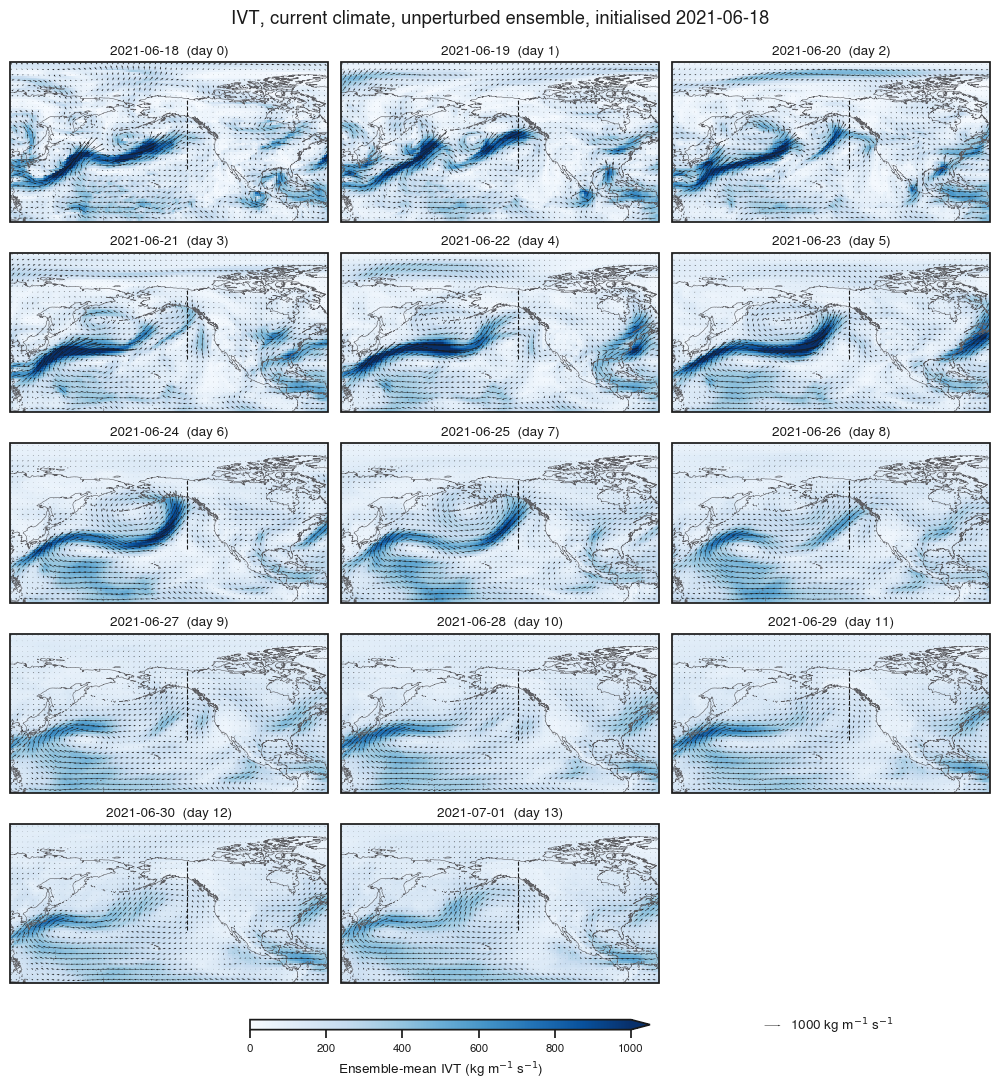

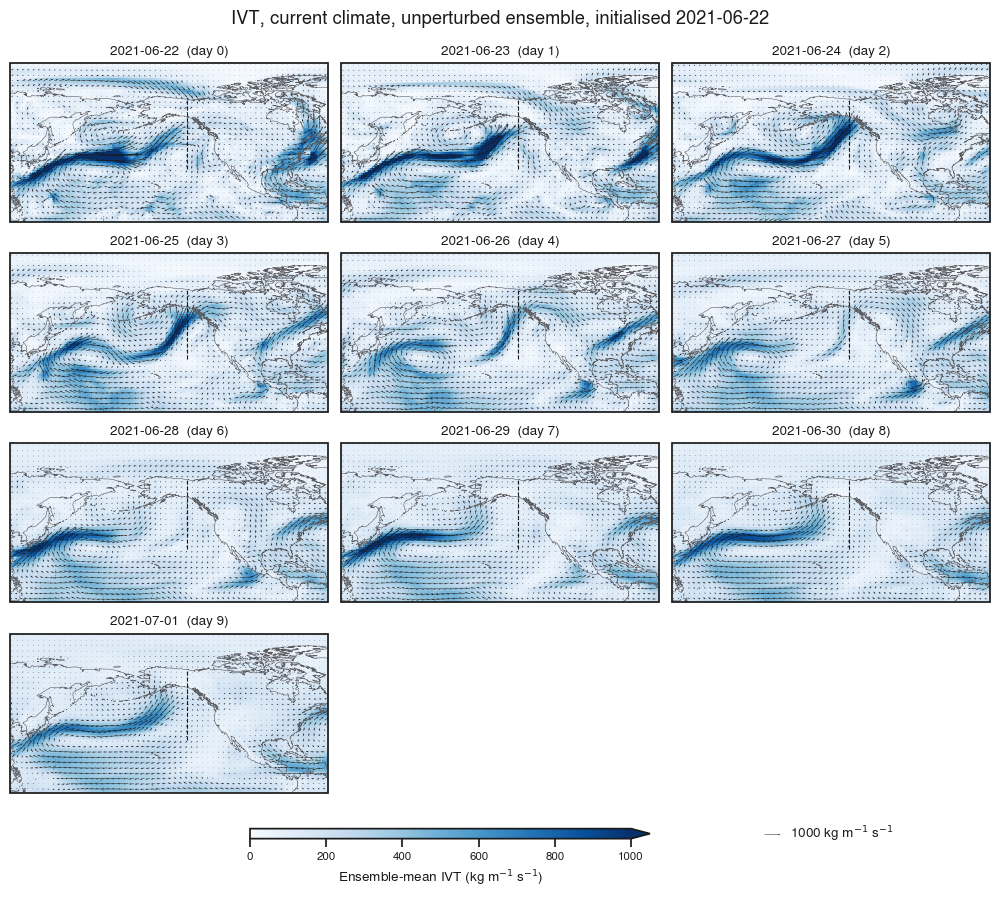

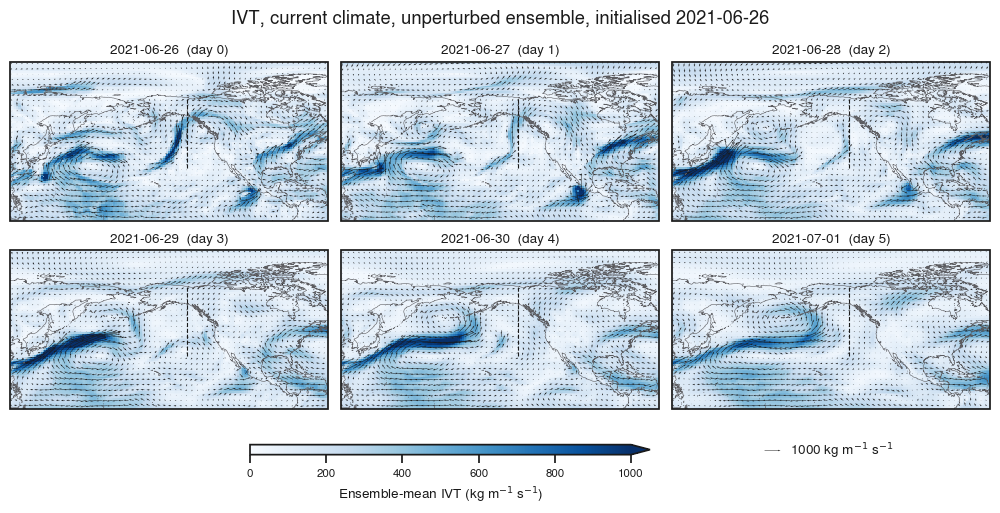

In [27]:
for inidate in ivt_unpert.inidate.values:
    ivt_daily_maps(ivt_unpert, inidate)

# Plotting the corner plot

One row per ensemble member (IFS, M-climate) or year (ERA5), with

- **t2m, tcwv, tcc, swvl1**: PNW-box mean at the time of the maximum box-mean t2m,
  26 June - 1 July for the IFS runs and the M-climate (the 21 and 24 June model
  dates either side of the 22 June runs, at lead 120-240 h and 48-168 h), 26-30
  June of each year for ERA5
- **z500_max**: maximum z500 over 35-60°N, 230-250°E, and **z500_blo**: z500 at
  40°N minus 60°N averaged over 230-250°E, both on the day of maximum z500_max in
  the same window
- **AR_strength**: mean IVT over the points on the 220°E section (30-70°N) where
  IVT exceeds 300 kg m⁻¹ s⁻¹, 24-25 June, and **AR_lat**: the IVT-weighted mean
  latitude of those points. Only ERA5 2021 has AR values among the ERA5 years, and
  the 26 June runs have none.

Saved in the units of the data (K, m² s⁻², kg m⁻², kg m⁻¹ s⁻¹); the plots convert
t2m to °C and z500 to dam.

In [28]:
# one frame per source, keyed the same way, then stacked
IDX = ['climate', 'perturbation', 'inidate', 'number']

# IFS runs: surface at the t2m peak, z500 at the z500 peak, AR on 24-25 June
ifs_df = (exp_max_df.reorder_levels(IDX)
          .join(ifs_z500_df.reorder_levels(IDX).drop(columns=['time', 'level']), how='outer')
          .join(ifs_AR_df.reorder_levels(IDX), how='left')
          .reset_index())
ifs_df['dataset'] = 'IFS'

mclim_df = mclim_max_df.join(mclim_z500_df.drop(columns=['hour']), how='outer').reset_index()
mclim_df['time'] = mclim_df.hDate + pd.to_timedelta(mclim_df.hour.values, unit='h')
mclim_df['dataset'] = 'M-climate'

# ERA5: one row per year, matched on the year rather than by position
era5_df = era5_max_df.reset_index()
era5_df['year'] = era5_df.time.dt.year
z = era5_z500_df.reset_index()
z['year'] = z.time.dt.year
era5_df = era5_df.merge(z.drop(columns=['time']), on='year', how='outer')
for k, v in era5_AR_info.items():
    era5_df[k] = np.where(era5_df.year == 2021, v, np.nan)
era5_df['dataset'] = 'ERA5'

COLUMNS = ['dataset', 'climate', 'perturbation', 'inidate', 'number', 'hDate', 'year', 'time',
           't2m', 'msl', 'tcwv', 'tcc', 'swvl1', 'z500_max', 'z500_mean', 'z500_blo',
           'AR_lat', 'AR_strength', 'AR_dir', 'AR_width']
plot_df = pd.concat([ifs_df, mclim_df, era5_df], ignore_index=True).reindex(columns=COLUMNS)

In [29]:
# rows per source, and how many carry each index
(plot_df.groupby(['dataset', 'climate', 'perturbation', 'inidate'], dropna=False)
 [['t2m', 'tcc', 'swvl1', 'z500_max', 'AR_strength']].count())

t2m  tcc  swvl1  z500_max  \
dataset   climate perturbation   inidate                                 
ERA5      NaN     NaN            NaT          72   72     72        72   
IFS       curr    none           2021-06-18   51   51     51        51   
                                 2021-06-22   51   51     51        51   
                                 2021-06-26   51   51     51        51   
          incr    iterated       2021-06-18   51   51     51        51   
                                 2021-06-22   51   51     51        51   
                                 2021-06-26   51   51     51        51   
                  iterated_short 2021-06-18   51   51     51        51   
                                 2021-06-22   51   51     51         0   
                                 2021-06-26   51   51     51         0   
                  ocean          2021-06-18   51   51     51        51   
                                 2021-06-22   51   51     51        51   
                                 2021-06-26   51   51     51        51   
                  tq             2021-06-18   51   51     51        51   
                                 2021-06-22   51   51     51        51   
                                 2021-06-26   51   51     51        51   
          pi      iterated       2021-06-18   51   51     51        51   
                                 2021-06-22   51   51     51        51   
                                 2021-06-26   51   51     51        51   
                  iterated_short 2021-06-18   51   51     51        51   
                                 2021-06-22   51   51     51        51   
                                 2021-06-26   51   51     51        51   
                  ocean          2021-06-18   51   51     51        51   
                                 2021-06-22   51   51     51        51   
                                 2021-06-26   51   51     51        51   
                  tq             2021-06-18   51   51     51        51   
                                 2021-06-22   51   51     51        51   
                                 2021-06-26   51   51     51        51   
M-climate NaN     NaN            NaT         440  440    440       440   

                                             AR_strength  
dataset   climate perturbation   inidate                  
ERA5      NaN     NaN            NaT                   1  
IFS       curr    none           2021-06-18           48  
                                 2021-06-22           51  
                                 2021-06-26            0  
          incr    iterated       2021-06-18           50  
                                 2021-06-22           51  
                                 2021-06-26            0  
                  iterated_short 2021-06-18           51  
                                 2021-06-22            0  
                                 2021-06-26            0  
                  ocean          2021-06-18           46  
                                 2021-06-22           51  
                                 2021-06-26            0  
                  tq             2021-06-18           48  
                                 2021-06-22           51  
                                 2021-06-26            0  
          pi      iterated       2021-06-18           45  
                                 2021-06-22           51  
                                 2021-06-26            0  
                  iterated_short 2021-06-18           46  
                                 2021-06-22           51  
                                 2021-06-26            0  
                  ocean          2021-06-18           48  
                                 2021-06-22           51  
                                 2021-06-26            0  
                  tq             2021-06-18           50  
                                 2021-06-22           51  
                                 2021-0

In [30]:
# save data for later use
POSTPROC = '/gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/postproc'
os.makedirs(POSTPROC, exist_ok=True)

plot_df.to_csv(os.path.join(POSTPROC, '09_corner_plot_data.csv'), index=False)
# IVT on the 220E section for every member, to redo the AR indices without re-reading ifs_pl
ifs_IVT_sec.to_netcdf(os.path.join(POSTPROC, '09_ifs_ivt_220E_20210624-25.nc'))
ivt_unpert.to_netcdf(os.path.join(POSTPROC, '09_ifs_ivt_unperturbed_ensmean.nc'))
era5_IVT_sec.to_netcdf(os.path.join(POSTPROC, '09_era5_ivt_220E_20210624-25.nc'))
sorted(os.listdir(POSTPROC))

['09_corner_plot_data.csv',
 '09_era5_ivt_220E_20210624-25.nc',
 '09_ifs_ivt_220E_20210624-25.nc',
 '09_ifs_ivt_unperturbed_ensmean.nc']

In [31]:
# plotted columns: axis label, and the conversion from the saved units
CORNER_VARS = {'t2m': ('T2m\n(°C)', lambda x: x - 273.15),
               'tcwv': ('TCWV\n(kg m$^{-2}$)', None),
               'tcc': ('TCC\n(0-1)', None),
               'swvl1': ('SWVL1\n(m$^3$ m$^{-3}$)', None),
               'z500_max': ('Z500 max\n(dam)', lambda x: x / 98.0665),
               'z500_blo': ('Z500 40N-60N\n(dam)', lambda x: x / 98.0665),
               'AR_strength': ('AR IVT\n(kg m$^{-1}$ s$^{-1}$)', None),
               'AR_lat': ('AR latitude\n(°N)', None)}

# bounded variables, so their KDEs stop at the physical limits
KDE_CLIP = {'tcc': (0, 1), 'swvl1': (0, None)}

ERA5_YEARS = plot_df.loc[plot_df.dataset == 'ERA5', 'year']
ERA5_CLIM = f'ERA5 {ERA5_YEARS.min():.0f}-{ERA5_YEARS.max() - 1:.0f}'

# reference groups, drawn in both figures. ERA5 is black throughout, hollow circles
# for the climatology and a star (a dashed line on the diagonal) for 2021, so it
# cannot be mistaken for the grey of the current-climate runs; the M-climate is a
# light grey background with a filled KDE.
REFERENCE = {'M-climate': dict(color='#C4C4C4', marker='.', s=12, zorder=0, ls='-', fill=True),
             ERA5_CLIM: dict(color=atmicp.style.INK, marker='o', s=10, zorder=5, ls='-',
                             facecolors='none', edgecolors=atmicp.style.INK, linewidths=0.5),
             'ERA5 2021': dict(color=atmicp.style.INK, marker='*', s=110, zorder=20, ls='--')}

# one marker per perturbation, as the linestyles in the 08_predictability legend
MARKER = {'none': 'o', 'iterated': 's', 'iterated_short': 'D', 'tq': '^', 'ocean': 'P'}


def reference_rows(df):
    """M-climate and ERA5 rows, with their hue group set."""
    df = df[df.dataset.isin(['M-climate', 'ERA5'])].copy()
    df['group'] = df.dataset
    era5 = df.dataset == 'ERA5'
    df.loc[era5, 'group'] = np.where(df.loc[era5, 'year'] == 2021, 'ERA5 2021', ERA5_CLIM)
    return df


def diag_kde(x, label=None, color=None, styles=None, **kwargs):
    """KDE for a group, or a vertical line for ERA5 2021, which is one value."""
    x = x.dropna()
    ax = plt.gca()
    fill = styles[label].get('fill', False)
    if label == 'ERA5 2021':
        if len(x):
            ax.axvline(x.iloc[0], color=color, linestyle='--', linewidth=1.2, zorder=10)
    elif len(x) >= 5:
        sns.kdeplot(x=x, color=color, linestyle=styles[label]['ls'],
                    linewidth=0 if fill else 1.0, fill=fill, alpha=0.5 if fill else 1.0,
                    clip=KDE_CLIP.get(x.name), warn_singular=False, ax=ax)


def legend_handle(label, style):
    return Line2D([0], [0], label=label, color=style['color'], linestyle=style['ls'],
                  linewidth=1.0, marker=style['marker'], markersize=np.sqrt(style['s']) + 1,
                  markerfacecolor=style.get('facecolors', style['color']),
                  markeredgecolor=style.get('edgecolors', 'white'), markeredgewidth=0.5)


def corner_plot(df, groups, title, stem, legend_blocks, panel=1.2):
    """Corner plot of CORNER_VARS, one hue level per entry of `groups`.

    `groups` maps each value of df.group to its style, in drawing order. Columns
    no IFS row has a value for (the AR indices for the 26 June runs) are left out.
    """
    df = df[df.group.isin(groups)].copy()
    cols = [c for c in CORNER_VARS if df.loc[df.dataset == 'IFS', c].notnull().any()]
    for c in cols:
        convert = CORNER_VARS[c][1]
        if convert is not None:
            df[c] = convert(df[c])

    order = [k for k in groups if k in set(df.group)]
    g = sns.PairGrid(df, vars=cols, hue='group', hue_order=order,
                     palette=[groups[k]['color'] for k in order],
                     hue_kws={'marker': [groups[k]['marker'] for k in order],
                              's': [groups[k]['s'] for k in order],
                              'zorder': [groups[k]['zorder'] for k in order],
                              'facecolors': [groups[k].get('facecolors', groups[k]['color']) for k in order],
                              'edgecolors': [groups[k].get('edgecolors', 'white') for k in order],
                              'linewidths': [groups[k].get('linewidths', 0.3) for k in order]},
                     corner=True, diag_sharey=False, height=panel)
    g.map_lower(plt.scatter)
    g.map_diag(diag_kde, styles=groups)

    fig = g.figure
    for ax in g.axes.flat:
        if ax is None:
            continue
        for axis, get, set_ in ((ax.xaxis, ax.get_xlabel, ax.set_xlabel),
                                (ax.yaxis, ax.get_ylabel, ax.set_ylabel)):
            if get() in CORNER_VARS:
                set_(CORNER_VARS[get()][0], fontsize=atmicp.style.scaled(atmicp.style.FS_SMALL, fig))
            axis.set_major_locator(mticker.MaxNLocator(3))
        ax.tick_params(labelsize=atmicp.style.scaled(atmicp.style.FS_XSMALL, fig))

    # legend blocks side by side in the empty upper triangle
    fs = atmicp.style.scaled(atmicp.style.FS_ANNOT, fig)
    for x, (heading, entries) in zip(np.linspace(0.42, 0.80, len(legend_blocks)), legend_blocks):
        fig.legend(handles=[legend_handle(label, groups[label]) for label in entries if label in order],
                   title=heading, loc='upper left', bbox_to_anchor=(x, 0.96),
                   frameon=False, alignment='left', fontsize=fs,
                   title_fontproperties={'size': fs, 'weight': 'bold'},
                   handlelength=1.8, labelspacing=0.5, borderpad=0.0)

    fig.suptitle(title, fontsize=atmicp.style.scaled(atmicp.style.FS_TITLE, fig), y=1.0)
    atmicp.style.save(fig, stem)
    plt.show()
    return g

## Unperturbed ensemble by lead time

The current-climate, unperturbed runs against the M-climate and ERA5, one colour
per initialisation date: lighter is a longer lead.

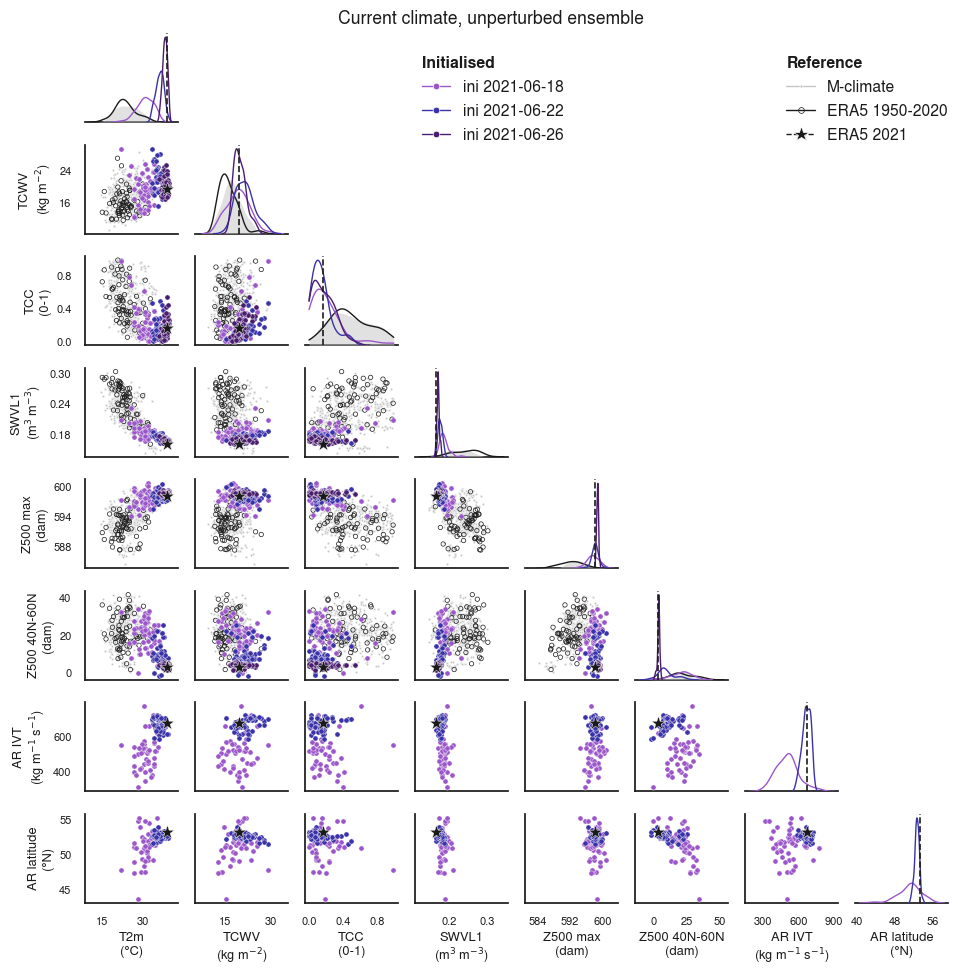

In [32]:
unpert = plot_df[(plot_df.dataset == 'IFS') & (plot_df.climate == 'curr')
                 & (plot_df.perturbation == 'none')].copy()
unpert['group'] = 'ini ' + unpert.inidate.dt.strftime('%Y-%m-%d')

inidates = sorted(unpert.group.unique())
# the three accents run light -> dark in this order, so the longest lead is lightest
lead_color = dict(zip(inidates, [atmicp.style.accent(k) for k in ('orchid', 'indigo', 'violet')]
                      if len(inidates) == 3 else sns.color_palette('flare_r', len(inidates))))
groups = {'M-climate': REFERENCE['M-climate'], ERA5_CLIM: REFERENCE[ERA5_CLIM],
          **{k: dict(color=lead_color[k], marker='o', s=14, zorder=10, ls='-') for k in inidates},
          'ERA5 2021': REFERENCE['ERA5 2021']}

g = corner_plot(pd.concat([reference_rows(plot_df), unpert]), groups,
                title='Current climate, unperturbed ensemble',
                stem='09_corner_unperturbed',
                legend_blocks=[('Initialised', inidates), ('Reference', list(REFERENCE))])

## Climate experiments, one figure per initialisation

Colour is the climate and marker (and KDE linestyle) the perturbation, as in
08_predictability.

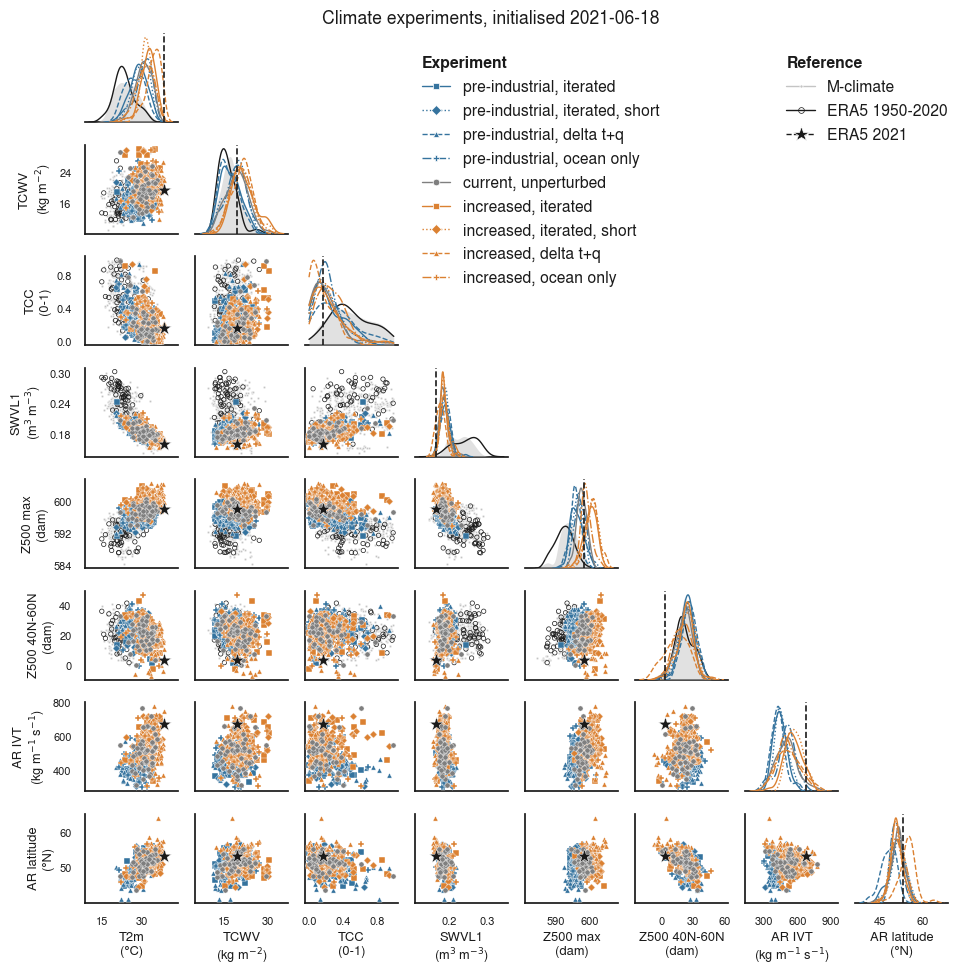

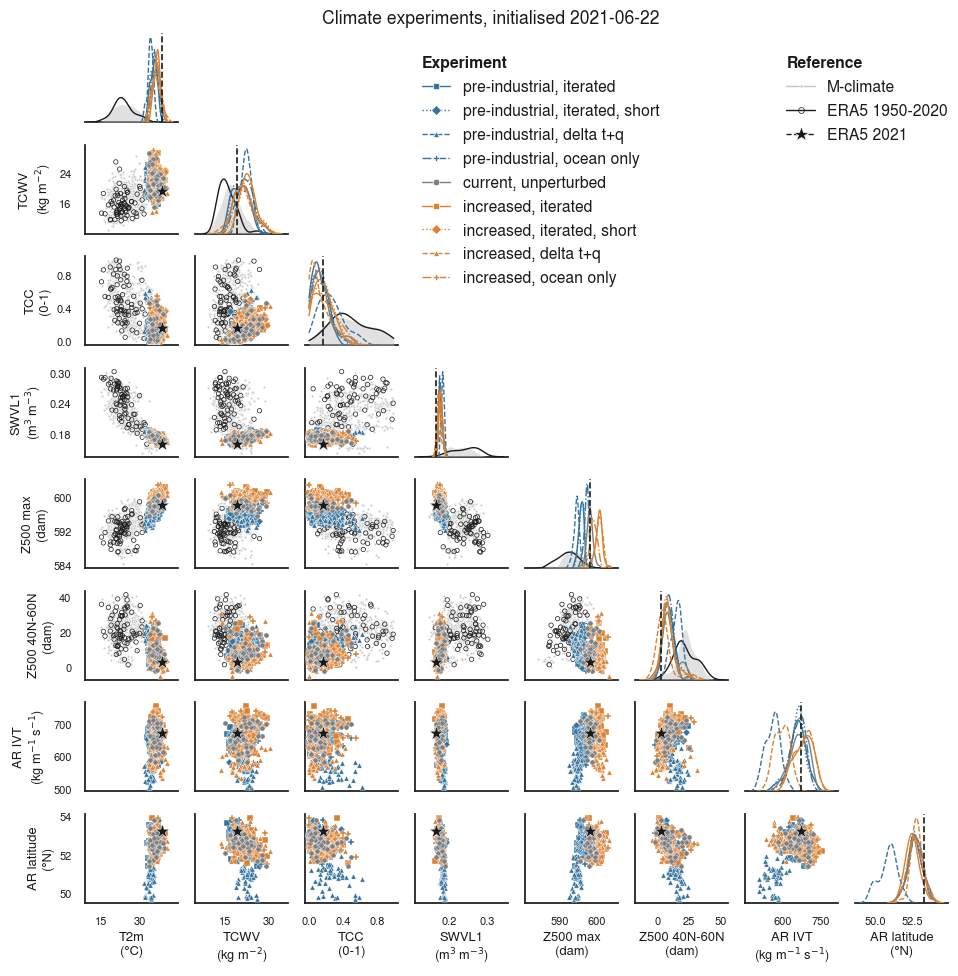

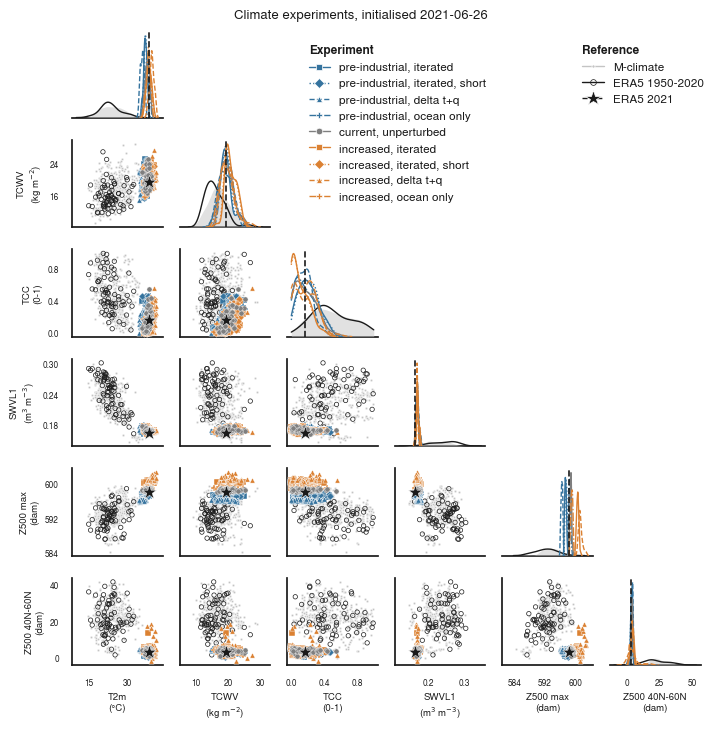

In [33]:
ifs_rows = plot_df[plot_df.dataset == 'IFS']

for inidate in sorted(ifs_rows.inidate.unique()):
    exp = ifs_rows[ifs_rows.inidate == inidate].copy()
    exp['group'] = exp.climate.map(LABEL) + ', ' + exp.perturbation.map(PERT_LABEL)

    groups = {'M-climate': REFERENCE['M-climate'], ERA5_CLIM: REFERENCE[ERA5_CLIM]}
    for c in ['pi', 'curr', 'incr']:
        for p in PERT_LABEL:
            if ((exp.climate == c) & (exp.perturbation == p)).any():
                # the unperturbed run on top, as the baseline the others move from
                groups[f'{LABEL[c]}, {PERT_LABEL[p]}'] = dict(color=CLIM[c], marker=MARKER[p], s=14,
                                                              zorder=11 if p == 'none' else 10, ls=LS[p])
    groups['ERA5 2021'] = REFERENCE['ERA5 2021']

    date = pd.Timestamp(inidate)
    corner_plot(pd.concat([reference_rows(plot_df), exp]), groups,
                title=f'Climate experiments, initialised {date:%Y-%m-%d}',
                stem=f'09_corner_experiments_{date:%Y%m%d}',
                legend_blocks=[('Experiment', [k for k in groups if k not in REFERENCE]),
                               ('Reference', list(REFERENCE))])